# Classifying scanner-data products into COICOP 2018 for CPI production

**A practical walkthrough of the UN-CEBD Scanner Data Task Team classification methodology.**

This notebook demonstrates, on a realistic (but small and fully public) dataset, the
classification methods described in the
[UN-CEBD Scanner Data Wiki — Classification chapter](https://unstats.un.org/wiki/display/GWGSD/Classification)
of the *Handbook on utilising new data sources in the production of consumer price statistics*:

| Method | What it is | Section |
|---|---|---|
| **0 — Manual labelling** | hand-labelling / validation of predicted labels ("golden dataset", selective editing) | 3 |
| **1 — Attribute-based** | deterministic rules on structured attributes (retailer category -> COICOP) | 4 |
| **2 — Pattern matching** | keywords / regular expressions on product text | 5 |
| **3 — Machine-assisted recommendation** | top-N recommendations for a human labeller | 6 |
| **4 — Machine learning** | TF-IDF + linear classifiers, and zero-shot NLI with a pretrained transformer | 7 |

plus the cross-cutting topics the handbook stresses:

- **evaluation** of classifiers the CPI way (precision-first, macro/micro F1, F-beta, confusion matrix) — section 8
- **class imbalance** (distribution test, resampling strategies) — section 9
- a mini **production loop** on a monthly churn batch: coverage reports, drift alarm, validation sample, retraining — section 10

> **Why precision matters here.** Misclassification feeds *wrong prices* into elementary
> aggregates: false positives pollute a COICOP class with prices that do not belong to it,
> biasing the index. The handbook (and the research it cites, e.g. Spackman et al. 2024)
> therefore recommends prioritising **precision over recall** when tuning classifiers for CPI use.

## Data

Products come from the **manual records** of
[COICOP 2018 classification — manual and synthetic (Zenodo, DOI 10.5281/zenodo.18459651)](https://zenodo.org/records/18459651),
~5,000 real product names manually labelled to COICOP 2018 by the dataset authors (CC-BY-SA 4.0).
We keep a 15-class subset (divisions 01-02: food and alcoholic beverages; 3,442 products) and
**augment** it with the structured attributes a scanner feed typically carries but the Zenodo
file lacks (outlet banner, promotion flag, GTIN, first-seen month — generated deterministically
with a fixed seed), and parse further attributes out of the product names (brand, pack size,
organic flag). The exact pipeline is `src/prepare_data.py` in this repository.

COICOP titles and definitions come from the official
[UNSD COICOP 2018 structure file](https://unstats.un.org/unsd/classifications/Econ/Download/COICOP_2018_English_structure.xlsx).

**Method comparison setup.** The Zenodo manual labels are our ground truth. Each method is
applied to the *same* held-out month (February 2025, 1,039 products never used to build rules
or train models), so scores are directly comparable across the whole toolbox.

## Setup

In [1]:
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_colwidth", 60)

# locate the repo root whether the kernel starts there or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data" / "processed").exists():
    for _p in [ROOT, *ROOT.parents]:
        if (_p / "data" / "processed").exists():
            ROOT = _p
            break
DATA = ROOT / "data"
PROC = DATA / "processed"

products = pd.read_csv(PROC / "products_train.csv", dtype={"gtin": str, "coicop_code": str})
mapping_table = pd.read_csv(PROC / "category_mapping_table.csv", dtype={"mapped_code": str})
production_batch = pd.read_csv(PROC / "production_batch.csv", dtype={"gtin": str})

print(f"{len(products):,} unique products | {products['coicop_code'].nunique()} COICOP classes")
products.head(3)

3,442 unique products | 15 COICOP classes


,gtin,name,brand,pack_size,is_organic,banner,is_promo,retailer_category,coicop_code,coicop_title,first_seen_month
0,0552487298145,albicocche i 45+ ita,NaN,NaN,False,DiscountOra,False,ortofrutta frutta fresca,01.1.6.3,"Stone fruits and pome fruits, fresh",2025-01
1,1595862830445,mevante montefalco sagrantino 75ml,NaN,75 ml,False,CoopNord,False,wine,02.1.2.1,Wine from grapes,2025-01
2,0438190435942,f&v clementine foglia cat.i cl2/3 it al kg,F&v,NaN,False,SuperBuy,False,ortofrutta frutta fresca,01.1.6.2,"Citrus fruits, fresh",2025-01


## 1. The classification task in a CPI production line

The handbook frames classification as the step that turns prepared data into strata:
every price in the dataset must be assigned to a category that supports
[index aggregation](https://unstats.un.org/wiki/display/GWGSD/Aggregation).
Two practical consequences drive everything in this notebook:

1. **Classify unique products, not rows.** A single GTIN can generate 100,000+ transaction
   rows per year (365 days x 400 stores). Classification is done once per unique product
   and then propagated — so the *scale* of the task is driven by the number of unique
   products and, in production, by the monthly **churn** of new ones.
2. **The output feeds elementary aggregates.** A misclassified product injects prices into
   the wrong stratum; classification quality is therefore a *price-statistics* problem, not
   just an ML problem — hence the handbook's emphasis on evaluation metrics and validation.

Before choosing a method the handbook ([Pre-conditions and deciding on appropriate
classification methods](https://unstats.un.org/wiki/display/GWGSD/Pre-conditions+and+deciding+on+appropriate+classification+methods))
asks: *how large is the task (products + churn)? how homogeneous are the target classes?
how stable are the data variables? how similar is the retailer's hierarchy to the NSO's
classes?* Let's look at our data through that lens.

In [2]:
# Scale of the task, handbook Table 1 style
initial = products[products["first_seen_month"] == "2025-01"]
churn = products[products["first_seen_month"] == "2025-02"]

scale = pd.DataFrame({
    "# unique products (initial month)": [len(initial)],
    "# new products next month (churn)": [len(churn)],
    "churn rate": [f"{len(churn) / len(initial):.0%}"],
    "# COICOP classes": [products["coicop_code"].nunique()],
})
scale

,# unique products (initial month),# new products next month (churn),churn rate,# COICOP classes
0,2403,1039,43%,15


,coicop_title,n
coicop_code,,
01.1.2.2,"Meat, fresh, chilled or frozen",584
01.1.6.3,"Stone fruits and pome fruits, fresh",447
02.1.2.1,Wine from grapes,420
01.1.2.3,"Meat, dried, salted, in brine or smoked",274
01.1.2.5,"Preparations of meat, offal, blood and other parts of sl...",244
01.1.9.1,Ready-made food,241
01.1.7.1,"Leafy or stem vegetables, fresh or chilled",232
01.1.6.2,"Citrus fruits, fresh",190
01.2.1.0,Fruit and vegetable juices,189


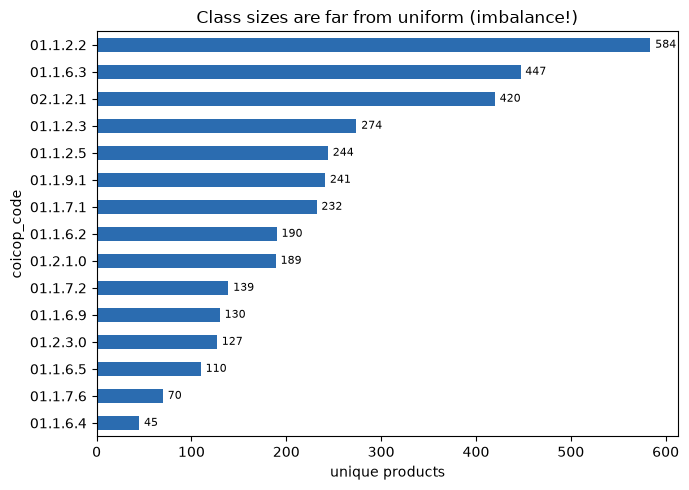

In [3]:
# Class sizes: homogeneity vs complexity trade-off (handbook Figure 2 discussion)
counts = products["coicop_code"].value_counts().rename("n")
titles = products.groupby("coicop_code")["coicop_title"].first()
class_table = pd.concat([titles, counts], axis=1).sort_values("n", ascending=False)
display(class_table)

ax = class_table["n"].plot.barh(figsize=(7, 5), color="#2b6cb0")
ax.invert_yaxis()
ax.set_xlabel("unique products")
ax.set_title("Class sizes are far from uniform (imbalance!)")
for i, v in enumerate(class_table["n"]):
    ax.text(v + 5, i, str(v), va="center", fontsize=8)
plt.tight_layout(); plt.show()

In [4]:
# Data-quality lens: how complete are the candidate variables?
quality = pd.DataFrame({
    "variable": ["name", "brand", "pack_size", "is_organic", "banner", "is_promo", "retailer_category"],
    "filled": [products[c].notna().mean() for c in
               ["name", "brand", "pack_size", "is_organic", "banner", "is_promo", "retailer_category"]],
})
quality["null"] = 1 - quality["filled"]
display(quality)

# Stability check across the two months for the key structured variable
jan_cats = set(initial["retailer_category"])
feb_cats = set(churn["retailer_category"])
print(f"retailer categories in Jan: {len(jan_cats)}, in Feb: {len(feb_cats)}")
print(f"categories seen in Feb but not in Jan (new attributes -> rule breaks!): {sorted(feb_cats - jan_cats)}")

,variable,filled,null
0,name,1.000000,0.000000
1,brand,0.239977,0.760023
2,pack_size,0.436374,0.563626
3,is_organic,1.000000,0.000000
4,banner,1.000000,0.000000
5,is_promo,1.000000,0.000000
6,retailer_category,1.000000,0.000000


retailer categories in Jan: 65, in Feb: 56
categories seen in Feb but not in Jan (new attributes -> rule breaks!): ['drinks | wine | non-alcoholic wines', 'food cupboard groceries | tea | decaf & all classic teas']


## 2. Ground truth, train/test design

Following the handbook's guidance for ML (and for honest evaluation of *any* method):

- the **initial classification** exercise uses month 1 (January 2025): rules are derived,
  keyword lists built, models trained on it;
- month 2 (February 2025) is the **hold-out** simulating out-of-sample production data:
  every method below is scored on exactly these 1,039 products.

This mirrors the handbook's advice to keep a hold-out that represents what the classifier
will meet in production, and to split by time so no future information leaks into rule or
model development.

In [5]:
train = products[products["first_seen_month"] == "2025-01"].copy()
test = products[products["first_seen_month"] == "2025-02"].copy()

CLASSES = sorted(products["coicop_code"].unique())
print(f"train: {len(train):,} | test: {len(test):,} | classes: {len(CLASSES)}")

from sklearn.metrics import precision_recall_fscore_support, accuracy_score

RESULTS = {}  # name -> (coverage, macro_precision, macro_recall, macro_f1)

def score_report(name, pred_series, test_df, min_support=20):
    """Precision-first report for any method producing labels (or NaN = unclassified)."""
    y_true = test_df["coicop_code"]
    y_pred = pred_series.reindex(test_df.index)
    covered = y_pred.notna()

    p, r, f1, sup = precision_recall_fscore_support(
        y_true[covered], y_pred[covered].astype(str), labels=CLASSES, zero_division=0)
    acc = accuracy_score(y_true[covered], y_pred[covered].astype(str))
    summary = pd.DataFrame({
        "code": CLASSES, "precision": p.round(3), "recall": r.round(3),
        "f1": f1.round(3), "support_true": sup,
    }).set_index("code").join(class_table[["coicop_title"]])
    macro = summary.loc[sup >= min_support, ["precision", "recall", "f1"]].mean()
    print(f"== {name} ==")
    print(f"coverage: {covered.mean():.1%} | accuracy (covered): {acc:.3f} | "
          f"macro-P: {macro['precision']:.3f} | macro-R: {macro['recall']:.3f} | macro-F1: {macro['f1']:.3f}")
    return summary

def record(name, pred_series, test_df, min_support=20):
    y_true = test_df["coicop_code"]; y_pred = pred_series.reindex(test_df.index)
    covered = y_pred.notna()
    p, r, f1, sup = precision_recall_fscore_support(
        y_true[covered], y_pred[covered].astype(str), labels=CLASSES, zero_division=0)
    mask = sup >= min_support
    RESULTS[name] = (float(covered.mean()), float(p[mask].mean()), float(r[mask].mean()), float(f1[mask].mean()))
    return RESULTS[name]

train: 2,403 | test: 1,039 | classes: 15


## 3. Method 0 — Manual labelling (and validation)

[Manual labelling page](https://unstats.un.org/wiki/display/GWGSD/Method+0%3A+Manual+labelling+or+validation+of+predicted+labels).

Manual classification remains the backbone: it produces the *golden dataset* every other
method is built and judged on, and in production it is the **validation** step that keeps
automated methods honest (GSBPM 5.3 "review and validate"). For huge tasks it is not viable
at scale, but *samples* of it always are.

Quality practices from the handbook we can show concretely:

- clear, unambiguous class definitions (we use the official COICOP 2018 titles and scope notes);
- consistency checks between labellers on a sample (inter-rater agreement);
- confidence scores and comments to route hard cases to experts.

Here we simulate a small labelling exercise: sample 40 products, "label" them with the
ground truth we already have, and measure how much a finite manual sample can tell us
about overall label quality (a bootstrap confidence interval on accuracy).

In [6]:
rng = np.random.default_rng(RANDOM_STATE)

# --- simulate a two-labeller exercise on a random sample -------------------
sample = test.sample(40, random_state=RANDOM_STATE)
# labeller B occasionally disagrees (5% of rows) - realistic noise
labeller_B = sample["coicop_code"].copy()
flip_idx = labeller_B.sample(frac=0.05, random_state=7).index
code_pos = {c: i for i, c in enumerate(CLASSES)}
labeller_B.loc[flip_idx] = [(CLASSES[(code_pos[c] + 1) % len(CLASSES)]) for c in labeller_B.loc[flip_idx]]

agree = (sample["coicop_code"] == labeller_B).mean()
print(f"Inter-rater agreement on the 40-product sample: {agree:.0%}")
print("Disagreements on rows:", list(flip_idx))

Inter-rater agreement on the 40-product sample: 95%
Disagreements on rows: [3326, 3364]


In [7]:
# --- what a validation sample tells us about a classifier -------------------
# Suppose an automated method has true accuracy 92%. A manual validation of n=100
# randomly drawn products estimates that accuracy; bootstrap shows the uncertainty.
true_acc = 0.92
n = 100
draws = rng.binomial(n, true_acc, size=2000) / n
lo, hi = np.percentile(draws, [2.5, 97.5])
print(f"validation of n={n} products -> accuracy estimate 95% CI [{lo:.2f}, {hi:.2f}]")
print("-> small validation samples are coarse: design their size knowing this spread.")

validation of n=100 products -> accuracy estimate 95% CI [0.86, 0.97]
-> small validation samples are coarse: design their size knowing this spread.


## 4. Method 1 — Attribute-based (rule-based) classification

[Attribute-based classification page](https://unstats.un.org/wiki/display/GWGSD/Method+1%3A+Attribute-based+classification+method).

The first method every NSO tries: if the retailer supplies stable structured attributes
(here: `retailer_category`), map them to COICOP classes with explicit rules. The handbook's
key requirements:

- build the mapping from labelled data (we use the January month, as if annotated during
  initial classification);
- store rules as **version-controlled data** (CSV/JSON in the repo, not spreadsheet magic);
- produce **break reports**: new/unseen attributes or sudden shifts in category sizes are
  the alarm signal that rules are failing.

`data/processed/category_mapping_table.csv` was built exactly this way from January. Let's
apply it to February and see both the power and the limits of pure attribute mapping.

In [8]:
# Rules as data: one row per retailer category (built from January, see prepare_data.py)
rules = mapping_table.set_index("retailer_category")["mapped_code"].to_dict()
display(mapping_table.head(8))

def apply_attribute_rules(df, rules):
    return df["retailer_category"].map(rules)

pred_m1_full = apply_attribute_rules(test, rules)

,retailer_category,n_products,mapped_code,purity,n_codes,mapped_title
0,ortofrutta frutta fresca,544,01.1.6.3,0.546,7,"Stone fruits and pome fruits, fresh"
1,ortofrutta verdure,379,01.1.7.1,0.412,6,"Leafy or stem vegetables, fresh or chilled"
2,formaggi e salumi salumi confezionati,166,01.1.2.3,0.837,2,"Meat, dried, salted, in brine or smoked"
3,carne bovina,162,01.1.2.2,0.926,3,"Meat, fresh, chilled or frozen"
4,wine,154,02.1.2.1,1.000,1,Wine from grapes
5,carne suina,115,01.1.2.2,0.626,3,"Meat, fresh, chilled or frozen"
6,carne avicunicola,107,01.1.2.2,0.935,2,"Meat, fresh, chilled or frozen"
7,carne ovi-caprina,68,01.1.2.2,0.971,2,"Meat, fresh, chilled or frozen"


In [9]:
summary_m1 = score_report("Method 1 (all categories)", pred_m1_full, test)
record("Method 1 (all categories)", pred_m1_full, test)
display(summary_m1.sort_values("precision").head(6))

== Method 1 (all categories) ==
coverage: 99.8% | accuracy (covered): 0.726 | macro-P: 0.606 | macro-R: 0.649 | macro-F1: 0.593


,precision,recall,f1,support_true,coicop_title
code,,,,,
01.1.6.2,0.000,0.000,0.000,57,"Citrus fruits, fresh"
01.1.6.4,0.000,0.000,0.000,14,"Berries, fresh"
01.1.6.5,0.000,0.000,0.000,33,"Other fruits, fresh"
01.1.7.2,0.000,0.000,0.000,42,"Fruit-bearing vegetables, fresh or chilled"
01.1.7.1,0.423,0.943,0.584,70,"Leafy or stem vegetables, fresh or chilled"
01.1.6.3,0.559,0.978,0.712,135,"Stone fruits and pome fruits, fresh"


In [10]:
# The purity column already warns us: several categories are mixed.
mixed = mapping_table[mapping_table["purity"] < 0.90].sort_values("n_products", ascending=False)
print(f"{len(mixed)} of {len(mapping_table)} categories have purity < 0.90")
display(mixed.head(6))

16 of 65 categories have purity < 0.90


,retailer_category,n_products,mapped_code,purity,n_codes,mapped_title
0,ortofrutta frutta fresca,544,01.1.6.3,0.546,7,"Stone fruits and pome fruits, fresh"
1,ortofrutta verdure,379,01.1.7.1,0.412,6,"Leafy or stem vegetables, fresh or chilled"
2,formaggi e salumi salumi confezionati,166,01.1.2.3,0.837,2,"Meat, dried, salted, in brine or smoked"
5,carne suina,115,01.1.2.2,0.626,3,"Meat, fresh, chilled or frozen"
8,ortofrutta frutta secca,67,01.1.6.9,0.836,5,"Fruits and nuts, ground, and in other preparations"
9,ortofrutta legumi e cereali,59,01.1.7.6,0.797,3,Pulses


In [11]:
# High-precision variant: trust a rule only where January showed purity >= 0.95
good_cats = set(mapping_table.loc[mapping_table["purity"] >= 0.95, "retailer_category"])
rules_hp = {k: v for k, v in rules.items() if k in good_cats}
pred_m1_hp = apply_attribute_rules(test, rules_hp)

summary_m1hp = score_report("Method 1 (purity>=0.95 only)", pred_m1_hp, test)
record("Method 1 (purity>=0.95 only)", pred_m1_hp, test)
# coverage collapses: that is the attribute-based trade-off (handbook: filter or refine)

== Method 1 (purity>=0.95 only) ==
coverage: 23.9% | accuracy (covered): 1.000 | macro-P: 1.000 | macro-R: 1.000 | macro-F1: 1.000


(0.2386910490856593, 1.0, 1.0, 1.0)

In [12]:
# Break report: the production guard-rail the handbook asks for
feb_new_cats = sorted(set(test["retailer_category"]) - set(rules))
print(f"NEW retailer categories in Feb not covered by any rule: {len(feb_new_cats)}")
for c in feb_new_cats[:10]:
    print("  -", c)
print("\nA new attribute value means the retailer re-organised (or a new supplier file arrived):")
print("rules must be reviewed before the data flows into index calculation.")

NEW retailer categories in Feb not covered by any rule: 2
  - drinks | wine | non-alcoholic wines
  - food cupboard groceries | tea | decaf & all classic teas

A new attribute value means the retailer re-organised (or a new supplier file arrived):
rules must be reviewed before the data flows into index calculation.


## 5. Method 2 — Pattern matching (keywords & regex)

[Pattern matching page](https://unstats.un.org/wiki/display/GWGSD/Method+2%3A+Pattern-matching+classification+method).

Where a category is too heterogeneous to map cleanly (look at `ortofrutta verdure` above:
it mixes leafy vegetables, ready-made salads and fruiting vegetables), the handbook
prescribes keyword/regex refinement — and explicitly suggests using pattern matches as
*boolean attributes* inside a rule system, or to impute missing attribute values.

We build a compact multilingual keyword dictionary (Italian + English, matching the data)
for the classes that live inside `ortofrutta verdure`, apply it as a decision-list
classifier, and score it on February. Note the handbook's warning: keyword lists are
fragile — they age as naming conventions change (see the production loop in section 10).

In [13]:
VEG_LEAFY = r"(insalat|lattuga|rucola|spinac|bietol|sedano|cicori|radicchi|indivia|valerian|carciof|asparag|broccol|cavol|finocchi|porr|scalogno|prezzemol|basilic|salad|chard|chicory|endive|lettuce|spinach|celery|fennel|artichoke|asparagus|broccoli|cabbage|leek|parsley|basil|kale)"
VEG_FRUITING = r"(pomodor|zucchin|zucchine|peperon|melanzan|cetriol|zucca|pepper|tomato|courgette|aubergine|cucumber|squash|chili|chilli)"
READY = r"(ready|pronto|cott|grigliat|grilled|steam|vapore|insalatine|condite|meal|kit|wrap|pasta|risotto|couscous|taboul|guacamole|hummus|burger)"

def classify_verdure_block(name: str):
    """Decision list inside the ambiguous 'ortofrutta verdure' category."""
    n = str(name).lower()
    if re.search(READY, n):
        return "01.1.9.1"
    if re.search(VEG_FRUITING, n):
        return "01.1.7.2"
    if re.search(VEG_LEAFY, n):
        return "01.1.7.1"
    return None  # unclassified -> mop-up

block = test["retailer_category"] == "ortofrutta verdure"
pred_m2 = pred_m1_full.copy()
pred_m2[block] = [classify_verdure_block(n) for n in test.loc[block, "name"]]

summary_m2 = score_report("Method 2 (M1 + verdure keywords)", pred_m2, test)
record("Method 2 (M1 + verdure keywords)", pred_m2, test)

== Method 2 (M1 + verdure keywords) ==
coverage: 97.3% | accuracy (covered): 0.786 | macro-P: 0.705 | macro-R: 0.740 | macro-F1: 0.699


(0.973051010587103, 0.7054685378594766, 0.7400363380165246, 0.6991774819196028)

In [14]:
# Where did the keywords fail? Inspect misclassifications inside the block
from sklearn.metrics import confusion_matrix

blk = test[block & pred_m2.notna()]
cm = confusion_matrix(blk["coicop_code"], pred_m2[blk.index],
                      labels=["01.1.7.1", "01.1.7.2", "01.1.9.1"])
cm_df = pd.DataFrame(cm, index=["true 01.1.7.1", "true 01.1.7.2", "true 01.1.9.1"],
                     columns=["pred 7.1", "pred 7.2", "pred 9.1"])
display(cm_df)

miss = blk[blk["coicop_code"] != pred_m2[blk.index]]
print(f"misclassified in block: {len(miss)} of {len(blk)}")
display(miss[["name", "retailer_category", "coicop_code"]].head(8))

,pred 7.1,pred 7.2,pred 9.1
true 01.1.7.1,60,0,0
true 01.1.7.2,0,37,0
true 01.1.9.1,18,4,11


misclassified in block: 22 of 130


,name,retailer_category,coicop_code
2343,insalata mista con carote e spinacino 220 g conad,ortofrutta verdure,01.1.9.1
2433,bonta di stagione riso & verdure carciofi e radicchio 300 g,ortofrutta verdure,01.1.9.1
2475,vellutata agli asparagi 620 g verso natura conad,ortofrutta verdure,01.1.9.1
2506,passato zucca carote/zenz.bonta di,ortofrutta verdure,01.1.9.1
2517,bis cavolfiore/broccol.cot.vap.250g,ortofrutta verdure,01.1.9.1
2536,vellutata zucca e carote con crostini croccanti 365 g ve...,ortofrutta verdure,01.1.9.1
2541,dimmidisi le zuppe fresche vellutata di patate e porri 6...,ortofrutta verdure,01.1.9.1
2603,zuppa cavolo nero bio alce nero580g,ortofrutta verdure,01.1.9.1


In [15]:
# Keyword-boolean attribute + null-value imputation, handbook style:
# pattern matches used as *attributes* to sharpen rules (here: organic flag recovery)
ORG_HINT = r"\b(bio|biologica|biologico|organic)\b"
recovered = test["is_organic"].isna() & test["name"].str.lower().str.contains(ORG_HINT, regex=True, na=False)
print(f"organic flag recovered from name text for {recovered.sum()} products")

# Same trick can support a size-based check on the wine rule
BOTTLE = r"75\s?cl|0\.?75\s?l|750\s?ml"
wine_hint = test["name"].str.contains(BOTTLE, case=False, regex=True) & (test["retailer_category"] == "wine")
print(f"wine-bottle size pattern matches: {wine_hint.sum()} (usable as an attribute check on the wine rule)")

organic flag recovered from name text for 0 products
wine-bottle size pattern matches: 14 (usable as an attribute check on the wine rule)


## 6. Method 3 — Machine-assisted classification (recommendation)

[Recommendation / machine-assisted page](https://unstats.un.org/wiki/display/GWGSD/Method+3%3A+Recommendation+%2F+Machine-assisted+classification).

A human stays in the loop, but the machine shortlists classes. The handbook lists three
recommender options: keyword-based, hierarchy-mapping, and an ML model returning
probabilities so the top-N classes can be offered to the labeller.

We show the ML-flavoured recommender built on January data only:
`LogisticRegression` over TF-IDF of product names, returning the **top-3 classes with
probabilities**. Metrics for a recommender are different: what matters is
**top-k accuracy / coverage** (how often the true class is in the shortlist) — the labeller
corrects the machine when needed, and each correction is free training data.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

def make_text(df):
    return (df["name"].fillna("") + " sep " + df["retailer_category"].fillna("")).str.lower()

def text_features(t_tr, t_te):
    vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    return vec.fit_transform(t_tr), vec.transform(t_te), vec

txt_tr, txt_te = make_text(train), make_text(test)
X_tr, X_te, vec = text_features(txt_tr, txt_te)
print(f"TF-IDF matrix: {X_tr.shape[0]} x {X_tr.shape[1]} (train)")

reco = LogisticRegression(max_iter=2000, C=5.0, random_state=RANDOM_STATE)
reco.fit(X_tr, train["coicop_code"])

TF-IDF matrix: 2403 x 3225 (train)


,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",5.0
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [17]:
# Top-3 recommendations for a sample of February products
proba = reco.predict_proba(X_te)
classes_r = reco.classes_
top3_idx = np.argsort(-proba, axis=1)[:, :3]

demo = test.sample(8, random_state=1)
for i in demo.index:
    pos = test.index.get_loc(i)
    row = [(classes_r[j], proba[pos, j]) for j in top3_idx[pos]]
    truth = test.loc[i, "coicop_code"]
    hit = "*" if truth in [c for c, _ in row] else " "
    print(f"{hit} {test.loc[i, 'name'][:45]:45s} true={truth}")
    print(f"    -> " + " | ".join(f"{c} ({p:.2f})" for c, p in row))

* louis eschenauer medoc                        true=02.1.2.1
    -> 02.1.2.1 (1.00) | 01.1.2.5 (0.00) | 01.1.9.1 (0.00)
* conad carne di bovino in gelatina 3 x 140 g   true=01.1.2.5
    -> 01.1.2.5 (0.92) | 01.1.2.2 (0.03) | 01.1.9.1 (0.01)
* la polenza cinque terre doc 750 ml            true=02.1.2.1
    -> 02.1.2.1 (0.99) | 01.2.1.0 (0.01) | 01.2.3.0 (0.00)
* salsicc.suino nero piccante madeo             true=01.1.2.5
    -> 01.1.2.5 (0.53) | 01.1.2.3 (0.44) | 01.1.2.2 (0.00)
* valfrutta a c e juice                         true=01.2.1.0
    -> 01.2.1.0 (0.99) | 01.1.6.9 (0.00) | 01.1.7.2 (0.00)
* rio d'oro mehrfruchtdirektsaft 1 l, ananas, o true=01.2.1.0
    -> 01.2.1.0 (0.90) | 01.2.3.0 (0.01) | 02.1.2.1 (0.01)
* lonza di suino a trancio                      true=01.1.2.2
    -> 01.1.2.2 (0.93) | 01.1.2.5 (0.03) | 01.1.9.1 (0.01)
* sk mango juice 1l                             true=01.2.1.0
    -> 01.2.1.0 (0.86) | 01.2.3.0 (0.04) | 02.1.2.1 (0.01)


In [18]:
# Recommender metrics: top-k coverage (hit rate)
truth_arr = test["coicop_code"].to_numpy()
top1 = np.array([classes_r[j] for j in top3_idx[:, 0]])
topk = [truth_arr[i] in [classes_r[j] for j in top3_idx[i]] for i in range(len(test))]
print(f"top-1 accuracy: {(top1 == truth_arr).mean():.1%}")
print(f"top-3 coverage (true class in shortlist): {np.mean(topk):.1%}")
print("\nA labeller picking from a 3-item shortlist that contains the truth most of the time")
print("is dramatically faster than navigating a 15-class hierarchy: the Method 3 efficiency argument.")

top-1 accuracy: 94.5%
top-3 coverage (true class in shortlist): 99.1%

A labeller picking from a 3-item shortlist that contains the truth most of the time
is dramatically faster than navigating a 15-class hierarchy: the Method 3 efficiency argument.


## 7. Method 4 — Machine learning classification

[ML classification page](https://unstats.un.org/wiki/display/GWGSD/Method+4%3A+Machine+Learning+classification+method).

Full automation: the model assigns the final COICOP code with no human in the loop
(validation moves to *sampling* — section 10). The handbook's recipe for the text side:

- **preprocess** product text (our names are short and messy: Italian + English, no
  sentences) — char n-grams are robust here, as they survive typos and morphology;
- **vectorise** with TF-IDF (bag-of-words to Word2Vec/FastText are mentioned; we use
  word + char TF-IDF);
- **model**: NSOs report good results with simple non-linear learners (SVM, XGBoost);
  probabilistic outputs are valuable for validation routing, so we compare
  `LogisticRegression`, `LinearSVC` and `ComplementNB` (designed for imbalanced text).

And one *embedding-era* addition the handbook anticipates via its Method 3 discussion:
**zero-shot classification** with a pretrained NLI transformer
(`facebook/bart-large-mnli`), which classifies into COICOP classes **without any
training data** — attractive when an NSO has no labels yet. We use the official COICOP
titles as candidate-label descriptions. (Runs on CPU; the 200-product sample below takes
a few minutes. On GPU/Colab it is much faster.)

**A caveat we must confront head-on:** BART-MNLI is English-centric while most of our
product names are Italian — a very common situation for NSOs classifying non-English
retailer data with off-the-shelf models. We therefore also show the standard mitigation,
*translate-then-classify* (MarianMT it->en + BART-MNLI), and quantify both. The honest
comparison is the point: zero-shot is a cold-start tool, not a substitute for labels.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB
from sklearn.svm import LinearSVC
from scipy.sparse import hstack

def word_char_features(t_tr, t_te):
    word = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
    char = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
    Xw_tr, Xw_te = word.fit_transform(t_tr), word.transform(t_te)
    Xc_tr, Xc_te = char.fit_transform(t_tr), char.transform(t_te)
    return hstack([Xw_tr, Xc_tr]).tocsr(), hstack([Xw_te, Xc_te]).tocsr()

Xf_tr, Xf_te = word_char_features(txt_tr, txt_te)
print(f"combined word+char features: {Xf_tr.shape}")

models = {
    "LogisticRegression": LogisticRegression(max_iter=3000, C=5.0, random_state=RANDOM_STATE),
    "LinearSVC": LinearSVC(C=1.0, random_state=RANDOM_STATE),
    "ComplementNB": ComplementNB(alpha=0.3),
}
preds_m4 = {}
for name, m in models.items():
    m.fit(Xf_tr, train["coicop_code"])
    preds_m4[name] = pd.Series(m.predict(Xf_te), index=test.index)
    record(f"Method 4: {name}", preds_m4[name], test)
    score_report(f"Method 4: {name}", preds_m4[name], test)

combined word+char features: (2403, 15905)


== Method 4: LogisticRegression ==
coverage: 100.0% | accuracy (covered): 0.962 | macro-P: 0.964 | macro-R: 0.950 | macro-F1: 0.956


== Method 4: LinearSVC ==
coverage: 100.0% | accuracy (covered): 0.970 | macro-P: 0.973 | macro-R: 0.964 | macro-F1: 0.968
== Method 4: ComplementNB ==
coverage: 100.0% | accuracy (covered): 0.925 | macro-P: 0.926 | macro-R: 0.910 | macro-F1: 0.911


In [20]:
# Misclassification inspection: which classes confuse the best model?
best_name = max(preds_m4, key=lambda k: RESULTS[f"Method 4: {k}"][3])
best_pred = preds_m4[best_name]
cm_all = confusion_matrix(test["coicop_code"], best_pred, labels=CLASSES)
off = cm_all - np.diag(np.diag(cm_all))
pairs = []
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        if i != j and off[i, j] >= 5:
            pairs.append((int(off[i, j]), CLASSES[i], CLASSES[j]))
pairs.sort(reverse=True)
print(f"most confused pairs ({best_name}):")
for n, a, b in pairs[:8]:
    print(f"  {n:3d} x {a} ({class_table.loc[a, 'coicop_title'][:35]}) -> {b}")

most confused pairs (LinearSVC):
    5 x 01.1.2.5 (Preparations of meat, offal, blood ) -> 01.1.2.3


In [21]:
# ---- Zero-shot classification with facebook/bart-large-mnli ----------------
# No training data at all: the NLI model scores each COICOP *title* as a hypothesis
# against the product text. Attractive when no labels exist yet; also a useful
# cold-start source of weak labels.
ZS_AVAILABLE = False
try:
    from transformers import pipeline
    zs = pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=-1)
    ZS_AVAILABLE = True
except Exception as e:
    print("transformers/torch unavailable -> zero-shot section skipped:", repr(e)[:120])

zs_sample = test.sample(min(200, len(test)), random_state=RANDOM_STATE)
zs_labels = [f"{c} {t}" for c, t in zip(class_table.index, class_table["coicop_title"])]
label_to_code = dict(zip(zs_labels, class_table.index))

if ZS_AVAILABLE:
    preds_zs = {}
    for i, name in zip(zs_sample.index, zs_sample["name"]):
        out = zs(str(name), candidate_labels=zs_labels, multi_label=False)
        preds_zs[i] = label_to_code[out["labels"][0]]
    pred_zs_series = pd.Series(preds_zs)
    record("Method 4: zero-shot BART-MNLI (n=200)", pred_zs_series, zs_sample)
    score_report("Method 4: zero-shot BART-MNLI (n=200)", pred_zs_series, zs_sample)
    print("\nNote the language mismatch: mostly Italian product names vs an English-centric")
    print("NLI model. Accuracy is far below the supervised models — expected.")


# ---- Mitigation: translate-then-classify (MarianMT it->en + BART-MNLI) -----
# A standard NSO workaround for non-English source data.
if ZS_AVAILABLE:
    MT_AVAILABLE = False
    try:
        import torch
        from transformers import MarianMTModel, MarianTokenizer
        mt_name = "Helsinki-NLP/opus-mt-it-en"
        mt_tok = MarianTokenizer.from_pretrained(mt_name)
        mt_model = MarianMTModel.from_pretrained(mt_name)
        MT_AVAILABLE = True
    except Exception as e:
        print("MarianMT unavailable -> translation step skipped:", repr(e)[:120])

    if MT_AVAILABLE:
        enc = mt_tok(list(zs_sample["name"].astype(str)), return_tensors="pt",
                     padding=True, truncation=True, max_length=64)
        with torch.no_grad():
            dec = mt_model.generate(**enc, max_length=64)
        translated = mt_tok.batch_decode(dec, skip_special_tokens=True)
        print("sample translations:")
        for a, b in list(zip(zs_sample["name"], translated))[:4]:
            print(f"  {str(a)[:42]!r:45s} -> {b[:42]!r}")

        preds_zs_mt = {}
        for i, name_en in zip(zs_sample.index, translated):
            out = zs(name_en, candidate_labels=zs_labels, multi_label=False)
            preds_zs_mt[i] = label_to_code[out["labels"][0]]
        pred_zs_mt_series = pd.Series(preds_zs_mt)
        record("Method 4: translate + zero-shot (n=200)", pred_zs_mt_series, zs_sample)
        score_report("Method 4: translate + zero-shot (n=200)", pred_zs_mt_series, zs_sample)
        print("\nTranslation recovers a large share of the gap, but short noisy product names")
        print("are hard to translate — supervised models remain far ahead. Zero-shot is a")
        print("cold-start / weak-labelling tool, not a replacement for annotation.")

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

== Method 4: zero-shot BART-MNLI (n=200) ==
coverage: 100.0% | accuracy (covered): 0.165 | macro-P: 0.190 | macro-R: 0.283 | macro-F1: 0.218

Note the language mismatch: mostly Italian product names vs an English-centric
NLI model. Accuracy is far below the supervised models — expected.


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

sample translations:
  'pesca tabacchiera cal.a 500g it.ict'         -> 'tobacconist fishing cal.a 500g it.ict'
  'mirtilli spagna secchiello 300g ict'         -> 'blueberries spain bucket 300g ict'
  'bietola da costa italia cat. i'              -> 'chard from coast italy cat. i'
  'bresaola valt.igp fr.&soffici conad'         -> 'bresaola valt.igp fr.&soffici conad'


== Method 4: translate + zero-shot (n=200) ==
coverage: 100.0% | accuracy (covered): 0.330 | macro-P: 0.375 | macro-R: 0.363 | macro-F1: 0.366

Translation recovers a large share of the gap, but short noisy product names
are hard to translate — supervised models remain far ahead. Zero-shot is a
cold-start / weak-labelling tool, not a replacement for annotation.


## 8. Evaluating classification methods — the CPI way

[How to evaluate classification methods](https://unstats.un.org/wiki/display/GWGSD/How+to+evaluate+classification+methods).

The handbook's evaluation chapter is built on the confusion matrix and its derived
metrics — with two price-statistics-specific twists:

1. **Precision first.** False positives contaminate a class with foreign prices -> bias
   in the elementary aggregate. False negatives mainly cost sample size. Hence F-beta
   with beta < 1 is a natural default.
2. **Macro vs micro.** Micro answers "how many products overall are right" (dominated by
   big classes); macro treats classes equally, which matches an index perspective where a
   small class can carry a large weight. With imbalanced data they diverge sharply.

Let's compute the full metric family on the best ML model, and visualise the confusion
matrix — the single most useful artefact to bring to a production review meeting.

In [22]:
from sklearn.metrics import fbeta_score

y_true, y_pred = test["coicop_code"], best_pred

p_mi, r_mi, f1_mi, _ = precision_recall_fscore_support(y_true, y_pred, average="micro", zero_division=0)
p_ma, r_ma, f1_ma, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
print("overall")
print(f"  accuracy           : {accuracy_score(y_true, y_pred):.3f}")
print(f"  precision (micro)  : {p_mi:.3f}")
print(f"  precision (macro)  : {p_ma:.3f}")
print(f"  recall (macro)     : {r_ma:.3f}")
print(f"  F1 (micro)         : {f1_mi:.3f}")
print(f"  F1 (macro)         : {f1_ma:.3f}")
for beta in (0.5, 1.0, 2.0):
    print(f"  F-beta (beta={beta:<4}) : {fbeta_score(y_true, y_pred, beta=beta, average='macro', zero_division=0):.3f}")

overall
  accuracy           : 0.970
  precision (micro)  : 0.970
  precision (macro)  : 0.967
  recall (macro)     : 0.966
  F1 (micro)         : 0.970
  F1 (macro)         : 0.966
  F-beta (beta=0.5 ) : 0.966
  F-beta (beta=1.0 ) : 0.966
  F-beta (beta=2.0 ) : 0.966


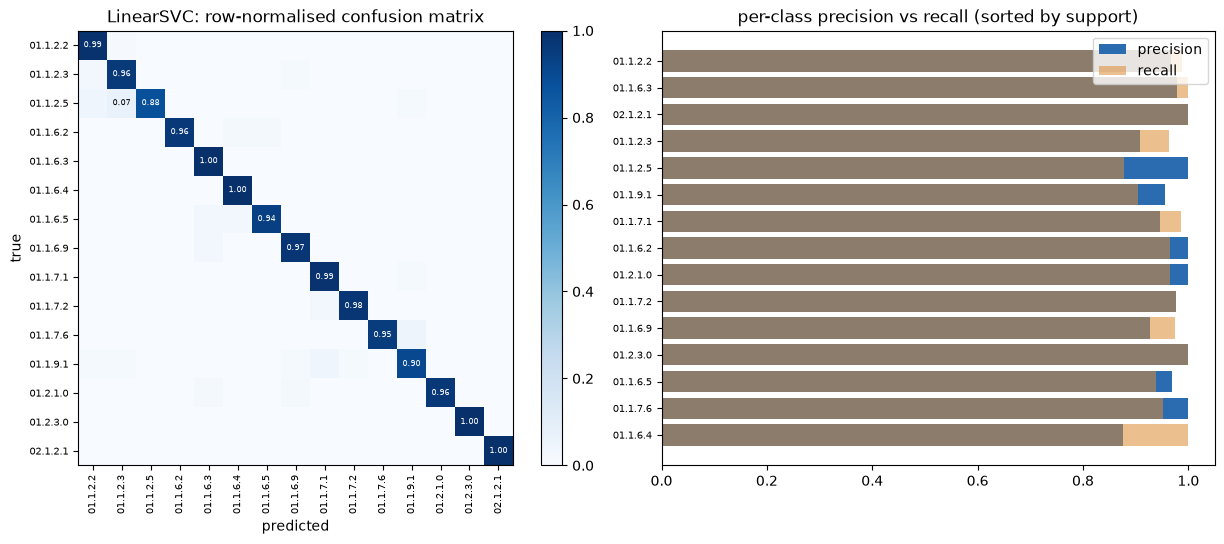

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
cm_norm = confusion_matrix(y_true, y_pred, labels=CLASSES, normalize="true")
im = axes[0].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
axes[0].set_xticks(range(len(CLASSES)), CLASSES, rotation=90, fontsize=7)
axes[0].set_yticks(range(len(CLASSES)), CLASSES, fontsize=7)
axes[0].set_xlabel("predicted"); axes[0].set_ylabel("true")
axes[0].set_title(f"{best_name}: row-normalised confusion matrix")
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        v = cm_norm[i, j]
        if v >= 0.05:
            axes[0].text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=5.5,
                         color="white" if v > 0.5 else "black")
plt.colorbar(im, ax=axes[0], fraction=0.046)

p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=CLASSES, zero_division=0)
order = np.argsort(-sup)
axes[1].barh(range(len(CLASSES)), p[order], color="#2b6cb0", label="precision")
axes[1].barh(range(len(CLASSES)), r[order], color="#dd8b34", alpha=0.55, label="recall")
axes[1].set_yticks(range(len(CLASSES)), [CLASSES[i] for i in order], fontsize=7)
axes[1].invert_yaxis(); axes[1].legend()
axes[1].set_title("per-class precision vs recall (sorted by support)")
plt.tight_layout(); plt.show()

In [24]:
# Method comparison scoreboard (all methods, same February hold-out)
rows = []
for name, (cov, mp, mr, mf1) in RESULTS.items():
    rows.append({"method": name, "coverage": round(cov, 3),
                 "macro-P": round(mp, 3), "macro-R": round(mr, 3), "macro-F1": round(mf1, 3)})
scoreboard = pd.DataFrame(rows).sort_values("macro-F1", ascending=False).reset_index(drop=True)
display(scoreboard)
scoreboard.to_csv(PROC / "method_scoreboard.csv", index=False)
print("written:", PROC / "method_scoreboard.csv")

,method,coverage,macro-P,macro-R,macro-F1
0,Method 1 (purity>=0.95 only),0.239,1.000,1.000,1.000
1,Method 4: LinearSVC,1.000,0.973,0.964,0.968
2,Method 4: LogisticRegression,1.000,0.964,0.950,0.956
3,Method 4: ComplementNB,1.000,0.927,0.910,0.911
4,Method 2 (M1 + verdure keywords),0.973,0.705,0.740,0.699
5,Method 1 (all categories),0.998,0.606,0.649,0.593
6,Method 4: translate + zero-shot (n=200),1.000,0.375,0.363,0.366
7,Method 4: zero-shot BART-MNLI (n=200),1.000,0.190,0.283,0.218


written: /home/ubuntu/coding/coicop-classification-notebook/data/processed/method_scoreboard.csv


## 9. Working with class imbalance

[Working with class imbalance](https://unstats.un.org/wiki/display/GWGSD/Working+with+class+imbalance).

Our classes span 584 to 45 products — mild but real imbalance, and the handbook's
example metrics (rice/flour/water) show how misleading accuracy becomes as imbalance
grows. Recommended arsenal, demonstrated below on the LogisticRegression pipeline:

1. **distribution test** — KS test of the class-frequency distribution against uniform
   (the handbook's formal check for "is this dataset imbalanced?");
2. **resampling / weighting** — random oversampling and SMOTE operate in feature space;
   for sparse text the handbook-appropriate equivalent is class-weighted training, which
   we show (under-sampling is skipped: the handbook itself notes it wastes scarce label data);
3. **decision policies** — precision-first operating points (auto-accept above a
   probability threshold, route the rest to manual validation = selective editing).

In [25]:
# 1) Distribution test: KS against uniform (handbook's recipe)
from scipy import stats

freq = test["coicop_code"].value_counts().sort_values()
ks_stat, ks_p = stats.kstest(freq / freq.sum(), "uniform")
print(f"KS statistic = {ks_stat:.3f}, p-value = {ks_p:.2e}")
if ks_p < 0.05:
    print("-> H0 (uniform class distribution) rejected: the dataset IS imbalanced.")

KS statistic = 0.831, p-value = 5.79e-12
-> H0 (uniform class distribution) rejected: the dataset IS imbalanced.


In [26]:
# 2) Class-weighted training vs plain training
plain = LogisticRegression(max_iter=3000, C=5.0, random_state=RANDOM_STATE)
balanced = LogisticRegression(max_iter=3000, C=5.0, class_weight="balanced", random_state=RANDOM_STATE)

for tag, m in [("plain", plain), ("class_weight=balanced", balanced)]:
    m.fit(Xf_tr, train["coicop_code"])
    pr = pd.Series(m.predict(Xf_te), index=test.index)
    p, r, f1, sup = precision_recall_fscore_support(test["coicop_code"], pr, labels=CLASSES, zero_division=0)
    minority = sup < 100
    print(f"{tag:24s} macro-F1 {f1.mean():.3f} | minority-recall {r[minority].mean():.3f} | "
          f"minority-precision {p[minority].mean():.3f}")
print("\nClass weighting lifts minority recall at a precision cost — exactly the trade-off the")
print("handbook describes. Whether that trade is right depends on the index use of the class.")

plain                    macro-F1 0.954 | minority-recall 0.937 | minority-precision 0.961


class_weight=balanced    macro-F1 0.956 | minority-recall 0.953 | minority-precision 0.947

Class weighting lifts minority recall at a precision cost — exactly the trade-off the
handbook describes. Whether that trade is right depends on the index use of the class.


In [27]:
# 3) Precision-first operating point: auto-accept above a probability threshold,
#    route the rest to manual validation (selective editing).
proba_best = plain.predict_proba(Xf_te)
conf = proba_best.max(axis=1)
pred_auto = pd.Series(plain.classes_[proba_best.argmax(axis=1)], index=test.index)
pred_auto[conf < 0.90] = np.nan  # below threshold -> manual queue

record("Method 4: LR + threshold 0.90", pred_auto, test)
score_report("Method 4: LR + threshold 0.90 (rest to manual)", pred_auto, test)

== Method 4: LR + threshold 0.90 (rest to manual) ==
coverage: 76.7% | accuracy (covered): 0.985 | macro-P: 0.989 | macro-R: 0.982 | macro-F1: 0.985


,precision,recall,f1,support_true,coicop_title
code,,,,,
01.1.2.2,0.971,0.988,0.979,169,"Meat, fresh, chilled or frozen"
01.1.2.3,0.926,0.974,0.949,77,"Meat, dried, salted, in brine or smoked"
01.1.2.5,1.000,0.882,0.938,51,"Preparations of meat, offal, blood and other parts of sl..."
01.1.6.2,1.000,1.000,1.000,42,"Citrus fruits, fresh"
01.1.6.3,1.000,1.000,1.000,113,"Stone fruits and pome fruits, fresh"
01.1.6.4,1.000,1.000,1.000,2,"Berries, fresh"
01.1.6.5,1.000,1.000,1.000,11,"Other fruits, fresh"
01.1.6.9,1.000,1.000,1.000,27,"Fruits and nuts, ground, and in other preparations"
01.1.7.1,0.976,1.000,0.988,40,"Leafy or stem vegetables, fresh or chilled"


## 10. A mini production loop (recurrent classification)

[Operational best practices](https://unstats.un.org/wiki/display/GWGSD/Operational+best+practices) •
[Designing the classification step](https://unstats.un.org/wiki/display/GWGSD/Designing+the+classification+step%3A+operational+considerations).

March arrives: `data/processed/production_batch.csv` contains the February carry-over plus
**25 genuinely new products** (new names, one new retailer category, one out-of-scope
energy drink). The recurrent process the handbook prescribes:

1. **coverage report** — how many new products the rules cover;
2. **break detection** — new attribute values, distribution-shift alarms;
3. **classification** — apply the production method to the new products;
4. **validation sample** — manually check a sample (random for unbiased performance
   estimates + low-confidence for correction), simulated with `new_products_truth.csv`;
5. **(conditional) retraining** — feed validated labels back and refresh the model.

Note how the out-of-scope product is caught by the coverage/break checks rather than
silently forced into a class.

In [28]:
march = production_batch.copy()
new_products = march[march["first_seen_month"] == "2025-03"]
print(f"March batch: {len(march)} products | {len(new_products)} new unique products (churn)")

# 1) coverage report -----------------------------------------------------
cov = march["retailer_category"].map(rules).notna().mean()
print(f"attribute-rule coverage on March batch: {cov:.1%}")

# 2) break detection ------------------------------------------------------
new_cats_march = sorted(set(march["retailer_category"]) - set(rules))
print(f"NEW retailer categories: {new_cats_march}")

# distribution shift alarm on the class mix of rule output (cheap KL check)
feb_mix = pred_m1_full.dropna().value_counts(normalize=True)
march_mix = march["retailer_category"].map(rules).dropna().value_counts(normalize=True)
eps = 1e-6
kl = sum(march_mix.get(c, eps) * np.log((march_mix.get(c, eps) + eps) / (feb_mix.get(c, eps) + eps))
         for c in set(feb_mix.index) | set(march_mix.index))
print(f"KL(class mix March || February) = {kl:.3f} (small = no big drift)")

March batch: 1064 products | 25 new unique products (churn)
attribute-rule coverage on March batch: 99.6%
NEW retailer categories: ['drinks | wine | non-alcoholic wines', 'food cupboard groceries | tea | decaf & all classic teas', "zucchero, caffe', te', infusi | te'"]
KL(class mix March || February) = 0.000 (small = no big drift)


In [29]:
# 3) classify the new products with the production model
#    (vectorisers refit on January training data only - never fit on production data)
wv = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
cv = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)
Xm = hstack([wv.fit_transform(txt_tr), cv.fit_transform(txt_tr)])
Xn = hstack([wv.transform(make_text(new_products)), cv.transform(make_text(new_products))]).tocsr()

prod_model = LogisticRegression(max_iter=3000, C=5.0, random_state=RANDOM_STATE)
prod_model.fit(Xm, train["coicop_code"])
new_pred = prod_model.predict(Xn)
new_proba = prod_model.predict_proba(Xn).max(axis=1)

result = new_products[["gtin", "name", "retailer_category"]].copy()
result["predicted_code"] = new_pred
result["confidence"] = new_proba.round(3)
display(result)

,gtin,name,retailer_category,predicted_code,confidence
1039,9900000000001,Fresh Ribeye Steak Angus 300g,carne bovina,01.1.2.2,0.641
1040,9900000000002,Organic Free-Range Chicken Fillets 500g,carne avicunicola,01.1.2.2,0.505
1041,9900000000003,Smoked Streaky Bacon 200g,carne suina,01.1.2.2,0.539
1042,9900000000004,Salami Felino PGI 250g,formaggi e salumi salumi confezionati,01.1.2.3,0.974
1043,9900000000005,Vienna Sausages in Brine 400g,scatolame carne in gelatina,01.1.2.5,0.890
1044,9900000000006,Blood Pudding Traditional 180g,carne suina,01.1.2.2,0.683
1045,9900000000007,Sicilian Oranges 1kg Bag,ortofrutta frutta fresca,01.1.6.3,0.532
1046,9900000000008,Lemon Juice Not From Concentrate 250ml,juices,01.2.1.0,0.963
1047,9900000000009,Pink Grapefruit Pack of 4,ortofrutta frutta fresca,01.1.6.3,0.505
1048,9900000000010,Golden Delicious Apples 1kg,ortofrutta frutta fresca,01.1.6.3,0.810


In [30]:
# 4) validation sample: 5 lowest-confidence + 5 random, checked against truth
truth_df = pd.read_csv(PROC / "new_products_truth.csv")
truth_map = dict(zip(truth_df["name"], truth_df["true_coicop"]))
result["true_code"] = result["name"].map(truth_map)

low_conf = result.nsmallest(5, "confidence").index
rand_val = result.drop(low_conf).sample(5, random_state=RANDOM_STATE).index
validated = result.loc[sorted(low_conf.union(rand_val))]

ok = (validated["predicted_code"] == validated["true_code"]) | (validated["true_code"] == "OUT-OF-SCOPE")
print(f"validation sample: {ok.sum()} of {len(validated)} checked products accepted as correct")
display(validated[["name", "predicted_code", "true_code", "confidence"]])

validation sample: 5 of 10 checked products accepted as correct


,name,predicted_code,true_code,confidence
1039,Fresh Ribeye Steak Angus 300g,01.1.2.2,01.1.2.2,0.641
1040,Organic Free-Range Chicken Fillets 500g,01.1.2.2,01.1.2.2,0.505
1047,Pink Grapefruit Pack of 4,01.1.6.3,01.1.6.2,0.505
1050,Wild Blueberries 250g,01.1.6.3,01.1.6.4,0.431
1051,Pomegranate Each,01.1.6.3,01.1.6.5,0.470
1052,Cherry Tomato Passata 700ml,01.1.7.1,01.1.7.2,0.501
1055,Borlotti Beans Canned 400g,01.1.9.1,01.1.7.6,0.470
1058,Earl Grey Tea 50 Teabags,01.2.3.0,01.2.3.0,0.994
1060,Primitivo di Manduria DOC 75cl,02.1.2.1,02.1.2.1,0.996
1063,Taurus Boost Energy Drink 500ml,01.2.1.0,OUT-OF-SCOPE,0.477


In [31]:
# The energy drink must be excluded from every in-scope class (handbook:
# out-of-scope products are better dropped than forced in - false positives bias indices)
oos = result[result["true_code"] == "OUT-OF-SCOPE"]
print("out-of-scope product caught by break checks:")
display(oos[["name", "retailer_category", "predicted_code", "confidence"]])
print("Its retailer category ('soft drinks') has no rule in our COICOP-01/02 basket and")
print("confidence is low: in production this row goes to the review queue, not the index.")

# 5) retraining with newly validated labels --------------------------------
good = validated[(validated["predicted_code"] == validated["true_code"]) & (validated["true_code"] != "OUT-OF-SCOPE")]
new_labelled = new_products.loc[good.index].assign(coicop_code=good["true_code"].values)
augmented = pd.concat([train, new_labelled])
Xa = hstack([wv.transform(make_text(augmented)), cv.transform(make_text(augmented))]).tocsr()
retrained = LogisticRegression(max_iter=3000, C=5.0, random_state=RANDOM_STATE)
retrained.fit(Xa, augmented["coicop_code"])
print(f"\nmodel retrained on {len(augmented)} products (was {len(train)}): "
      "quarterly-retrain cadence per the handbook's decay guidance")

out-of-scope product caught by break checks:


,name,retailer_category,predicted_code,confidence
1063,Taurus Boost Energy Drink 500ml,soft drinks,01.2.1.0,0.477


Its retailer category ('soft drinks') has no rule in our COICOP-01/02 basket and
confidence is low: in production this row goes to the review queue, not the index.



model retrained on 2407 products (was 2403): quarterly-retrain cadence per the handbook's decay guidance


## 11. What we learned — method selection guidance

The scoreboard summarises every method on the same February hold-out. The ranking
reproduces the handbook's decision logic:

- **Attribute rules (Method 1)** are unbeatable *where attributes are clean and stable*
  (wine, meat counters, juices): top precision, zero compute — but coverage collapses
  as soon as categories are heterogeneous. Start here.
- **Pattern matching (Method 2)** rescues heterogeneous categories with keyword
  decision-lists: cheap, explainable, a natural extension of Method 1 — but the lists
  age and need monitoring.
- **Recommendation (Method 3)** is not about accuracy: a top-3 shortlist containing the
  truth most of the time accelerates manual work while collecting training data.
- **ML (Method 4)** wins on overall macro-F1 and coverage, needs labelled data,
  monitoring and retraining — adopt it when scale demands it, keeping a validation
  sample forever.
- **Zero-shot NLI** needs *no labels at all* — a genuinely useful cold start and a weak
  labeller — but on this non-English data it trails supervised TF-IDF badly, and even
  with a translation front-end it does not close the gap. Use it to bootstrap labels,
  then train.

For an NSO the practical blueprint is the handbook's: measure the task scale and churn,
try rules first, mine what rules cannot reach with keywords, escalate to ML when volume
justifies MLOps — and always keep Method 0 (manual) in the loop as the ground truth and
safety net.

,method,coverage,macro-P,macro-R,macro-F1
0,Method 1 (purity>=0.95 only),0.239,1.000,1.000,1.000
1,Method 4: LR + threshold 0.90,0.767,0.989,0.982,0.985
2,Method 4: LinearSVC,1.000,0.973,0.964,0.968
3,Method 4: LogisticRegression,1.000,0.964,0.950,0.956
4,Method 4: ComplementNB,1.000,0.927,0.910,0.911
5,Method 2 (M1 + verdure keywords),0.973,0.705,0.740,0.699
6,Method 1 (all categories),0.998,0.606,0.649,0.593
7,Method 4: translate + zero-shot (n=200),1.000,0.375,0.363,0.366
8,Method 4: zero-shot BART-MNLI (n=200),1.000,0.190,0.283,0.218


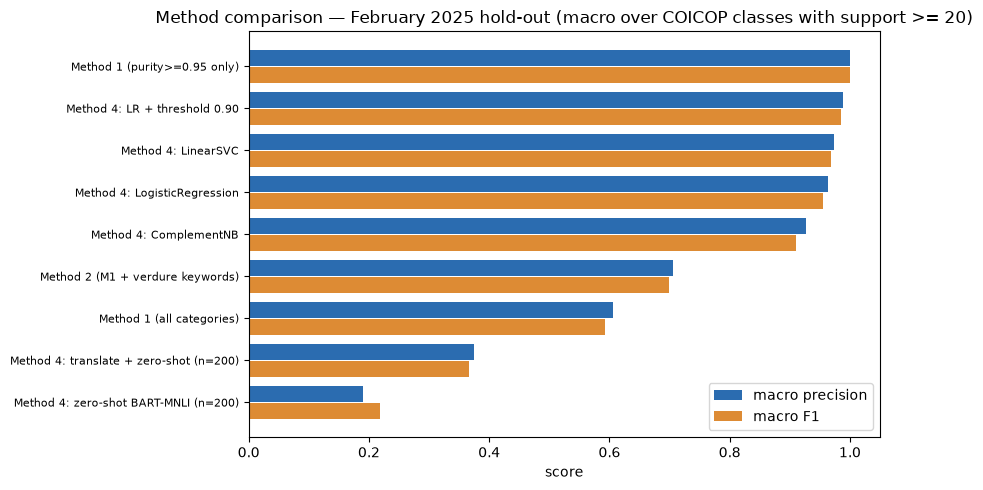

In [32]:
final = pd.DataFrame(
    [{"method": k, "coverage": round(v[0], 3), "macro-P": round(v[1], 3),
      "macro-R": round(v[2], 3), "macro-F1": round(v[3], 3)}
     for k, v in sorted(RESULTS.items(), key=lambda kv: -kv[1][3])]
)
display(final)

fig, ax = plt.subplots(figsize=(9, 5))
y = np.arange(len(final))
ax.barh(y - 0.2, final["macro-P"], height=0.38, label="macro precision", color="#2b6cb0")
ax.barh(y + 0.2, final["macro-F1"], height=0.38, label="macro F1", color="#dd8b34")
ax.set_yticks(y, final["method"], fontsize=8)
ax.invert_yaxis(); ax.legend(); ax.set_xlabel("score")
ax.set_title("Method comparison — February 2025 hold-out (macro over COICOP classes with support >= 20)")
plt.tight_layout(); plt.show()

## References & sources

- UN-CEBD Task Team on Scanner Data (2025). *Handbook on utilising new data sources in the
  production of consumer price statistics* — Classification chapter and sub-pages
  ([wiki space GWGSD](https://unstats.un.org/wiki/display/GWGSD/UN-CEBD+Task+Team+on+Scanner+Data)).
  The Task Team publishes accompanying code in its
  [classification_methods repository](https://github.com/UN-Task-Team-for-Scanner-Data/classification_methods).
- UN Statistics Division. *COICOP 2018 structure*
  ([download](https://unstats.un.org/unsd/classifications/Econ/Download/COICOP_2018_English_structure.xlsx)).
- Zenodo dataset: *COICOP 2018 classification — manual and synthetic*
  ([DOI 10.5281/zenodo.18459651](https://zenodo.org/records/18459651)), CC-BY-SA 4.0 — only the
  manual records are used here.
- Spackman, W. et al. (2024). *Machine Learning is (not!) all you need: Impact of
  classification-induced error on price indices using scanner data.* Ottawa Group.
- Ritter, C. et al. (2024). *Adopting a high-level MLOps practice for the production
  applications of machine learning in the Canadian CPI.* Statistics Canada.

**Reuse:** this notebook and code are MIT-licensed (see repository LICENSE). The derived
data files inherit the CC-BY-SA 4.0 licence of the Zenodo source dataset; the COICOP
structure is © United Nations.